In [1]:
# ============================================================
# 1. LOADING DATASETS (GOOGLE COLAB)
# ============================================================

"""from google.colab import files
uploaded = files.upload()"""


import pandas as pd
import numpy as np
from math import sqrt

# Replacing filenames
us = pd.read_csv("us_wildfire_2014_2025.csv")
# Reduceing US dataset to 1% for faster running
us = us.sample(frac=0.01, random_state=42).reset_index(drop=True)
print("US dataset reduced to:", us.shape)

paulo = pd.read_csv("forestfires.csv")

US dataset reduced to: (95099, 19)


In [2]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def find_area_column(df):
    """Detecting burned area column automatically."""
    for c in df.columns:
        if c.lower() in ['area', 'burned_area', 'burn_area']:
            return c
    raise ValueError("Burned area column not found.")


def prepare_us_dataset(df):
    """Map US wildfire variables to common feature names."""
    df = df.copy()

    # Temperature = average of daily min/max
    if 'tmmn' in df.columns and 'tmmx' in df.columns:
        df['temp'] = df[['tmmn', 'tmmx']].mean(axis=1)

    # Relative humidity = avg of rmin and rmax
    if 'rmax' in df.columns and 'rmin' in df.columns:
        df['RH'] = df[['rmax', 'rmin']].mean(axis=1)

    rename_map = {
        'vs': 'wind',  # Wind speed (vs): m/s
        'pr': 'rain',  # Precipitation (pr): mm/day
        'fm100': 'FFMC', # Fuel moisture indices (fm100/fm1000): %
        'fm1000': 'DC',
        'bi': 'ISI',  # Burning index (bi): index
        'erc': 'ERC'  # Energy release component (erc): index
    }

    df = df.rename(columns={c: rename_map[c] for c in rename_map if c in df.columns})
    return df



us = prepare_us_dataset(us)

# Common features
FEATURES = ["temp","RH","wind","rain","FFMC","DC","ISI","ERC"]
common_features = [f for f in FEATURES if f in us.columns and f in paulo.columns]
print("Common features used:", common_features)

us = us.dropna(subset=common_features)
paulo = paulo.dropna(subset=common_features)

Common features used: ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DC', 'ISI']


In [3]:
# ============================================================
# 3. PREPARE TARGET VARIABLES
# ============================================================

# Paulo dataset: fire = 1 if burned area > 0
paulo["fire"] = (paulo["area"] > 0).astype(int)

# US dataset: fire = 1 if Burning Index (ISI) > 0
us["fire"] = (us["ISI"] > 0).astype(int)

print("Paulo target counts:\n", paulo["fire"].value_counts())
print("US target counts:\n", us["fire"].value_counts())

Paulo target counts:
 fire
1    270
0    247
Name: count, dtype: int64
US target counts:
 fire
1    74392
0    20707
Name: count, dtype: int64


In [4]:
# ============================================================
# 4. TRAIN–TEST SPLIT AND SCALING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def split_scale_dataset(X, y):
    # Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    # Standard scaling
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    # MinMax scaling
    mm = MinMaxScaler().fit(X_train_s)
    X_train_s = mm.transform(X_train_s)
    X_test_s = mm.transform(X_test_s)
    return X_train_s, X_test_s, y_train, y_test

# US dataset
X_us = us[common_features].values
y_us = us["fire"].values
X_train_us_s, X_test_us_s, y_train_us, y_test_us = split_scale_dataset(X_us, y_us)

# Paulo dataset
X_pa = paulo[common_features].values
y_pa = paulo["fire"].values
X_train_pa_s, X_test_pa_s, y_train_pa, y_test_pa = split_scale_dataset(X_pa, y_pa)


In [5]:
# ============================================================
# 5. MODELS
# ============================================================

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "SVM": SVC(probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------
# ANN (Keras)
# ------------------------------

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    ann = Sequential([
        Dense(128, activation='relu', input_shape=(len(common_features),)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    ann.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    ann.fit(X_train_s, y_train, epochs=30, batch_size=32, verbose=0)

    class KerasWrapper:
        def __init__(self, model): self.model = model
        def predict_proba(self, X):
            p = self.model.predict(X, verbose=0).ravel()
            return np.vstack([1-p, p]).T

    models["ANN_Keras"] = KerasWrapper(ann)

except:
    print("TensorFlow not available — ANN skipped.")

TensorFlow not available — ANN skipped.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# ============================================================
# 6. TRAIN + EVALUATE FUNCTION
# ============================================================


from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, confusion_matrix

def evaluate_model(name, model, X, y, threshold=0.5):
    if hasattr(model,"predict_proba"):
        probs = model.predict_proba(X)[:,1]
    else:
        probs = model.predict(X)
    preds = (probs >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y,preds),
        "precision": precision_score(y,preds,zero_division=0),
        "recall": recall_score(y,preds,zero_division=0),
        "rmse": sqrt(mean_squared_error(y,probs))
    }

In [7]:
# ============================================================
# 7. TRAINING + EVALUATING MODELS
# ============================================================

results = []

datasets = [
    ("US Wildfire", X_train_us_s, X_test_us_s, y_train_us, y_test_us),
    ("Paulo Forest Fires", X_train_pa_s, X_test_pa_s, y_train_pa, y_test_pa)
]

for dataset_name, X_train_s, X_test_s, y_train, y_test in datasets:
    print(f"\n===== TRAINING ON {dataset_name} =====")

    for name, model in models.items():
        if name != "ANN_Keras":
            model.fit(X_train_s, y_train)
        res = evaluate_model(name, model, X_test_s, y_test)
        res["dataset"] = dataset_name
        results.append(res)

    # ANN trained separately for each dataset
    if 'ann' in locals():
        ann.fit(X_train_s, y_train, epochs=30, batch_size=32, verbose=0)
        class KerasWrapper:
            def __init__(self, model): self.model = model
            def predict_proba(self, X):
                p = self.model.predict(X, verbose=0).ravel()
                return np.vstack([1-p, p]).T
        ann_model = KerasWrapper(ann)
        res_ann = evaluate_model("ANN_Keras", ann_model, X_test_s, y_test)
        res_ann["dataset"] = dataset_name
        results.append(res_ann)



===== TRAINING ON US Wildfire =====

===== TRAINING ON Paulo Forest Fires =====


In [8]:
# ============================================================
# 9. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)
print("\n================ FINAL RESULTS ================\n")
print(results_df.to_string(index=False))

results_df.to_csv("model_comparison_results.csv", index=False)
print("\n Results saved as model_comparison_results.csv")


================ FINAL RESULTS ================

           model  accuracy  precision   recall     rmse            dataset
             SVM  0.998160   1.000000 0.997648 0.041394        US Wildfire
             MLP  0.998791   1.000000 0.998454 0.028082        US Wildfire
GradientBoosting  1.000000   1.000000 1.000000 0.000018        US Wildfire
       ANN_Keras  0.998686   1.000000 0.998320 0.033154        US Wildfire
             SVM  0.567308   0.552941 0.870370 0.495857 Paulo Forest Fires
             MLP  0.557692   0.557143 0.722222 0.498843 Paulo Forest Fires
GradientBoosting  0.586538   0.593220 0.648148 0.493784 Paulo Forest Fires
       ANN_Keras  0.538462   0.583333 0.388889 0.679366 Paulo Forest Fires

 Results saved as model_comparison_results.csv


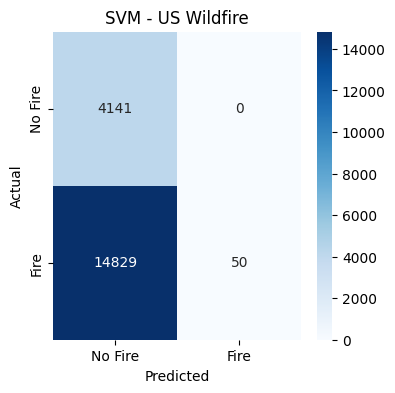

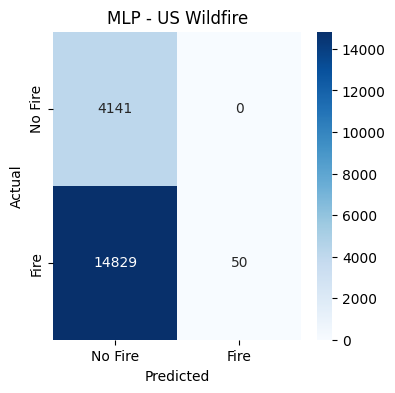

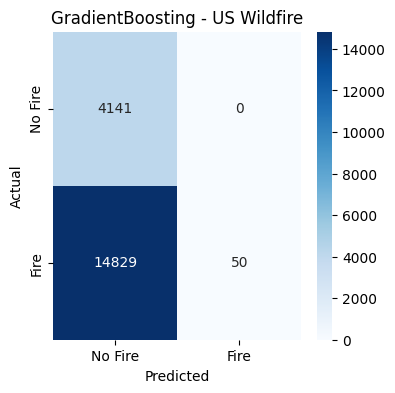

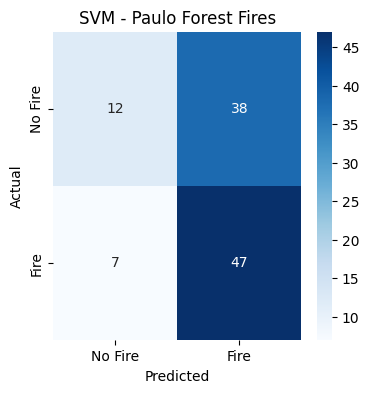

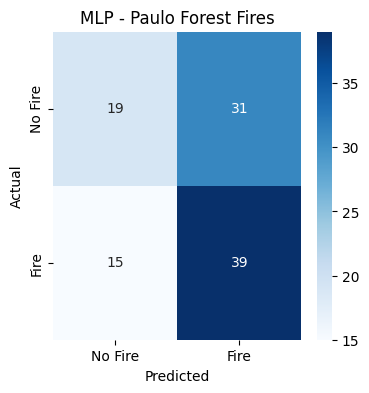

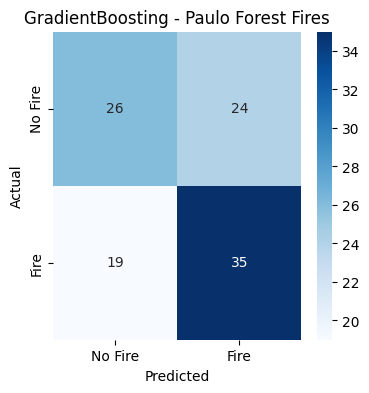

In [9]:
# ============================================================
# CONFUSION MATRICES FOR EACH MODEL (US + Paulo datasets)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_conf_matrix(model, X, y, title):
    # get predictions
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.predict(X)
    preds = (probs >= 0.5).astype(int)

    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Fire', 'Fire'],
                yticklabels=['No Fire', 'Fire'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Plot confusion matrices for each model
for dataset_name, X_train_s, X_test_s, y_train, y_test in datasets:
    for name, model in models.items():
        plot_conf_matrix(model, X_test_s, y_test, f"{name} - {dataset_name}")
